# MAE-Tiny 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
import os

CKPT_DIR        = './checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)


torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device = {device}")

device = cuda


---
# 0. DATESET

In [2]:
BATCH_SIZE = 128
IMG_SIZE   = 32

MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

transform_pretrain = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

pretrain_dataset = torchvision.datasets.STL10(root='./data', split='unlabeled',
                                                download=True, transform=transform_pretrain)

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=transform_train)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              download=True, transform=transform_test)

pretrain_loader = DataLoader(pretrain_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
train_loader    = DataLoader(train_dataset,    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader     = DataLoader(test_dataset,     batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sample_img, _ = train_dataset[0]
CHANNELS, H, W = sample_img.shape
NUM_CLASSES    = len(train_dataset.classes)

print(f"Pre-train size : {len(pretrain_dataset)}  (STL-10 unlabeled)")
print(f"Train size     : {len(train_dataset)}    (CIFAR-10)")
print(f"Test size      : {len(test_dataset)}")
print(f"Image size     : {CHANNELS} x {H} x {W}")
print(f"Num classes    : {NUM_CLASSES}")

Pre-train size : 100000  (STL-10 unlabeled)
Train size     : 50000    (CIFAR-10)
Test size      : 10000
Image size     : 3 x 32 x 32
Num classes    : 10


In [3]:
PATCH_SIZE  = 4
N_PATCHES   = (IMG_SIZE // PATCH_SIZE) ** 2          # 64
PATCH_DIM   = PATCH_SIZE ** 2 * CHANNELS              # 48

ENC_D_MODEL    = 128
ENC_NUM_HEADS  = 4
ENC_NUM_LAYERS = 6
ENC_D_FF       = 4 * ENC_D_MODEL                      # 512

DEC_D_MODEL    = 64
DEC_NUM_HEADS  = 4
DEC_NUM_LAYERS = 2
DEC_D_FF       = 4 * DEC_D_MODEL                      # 256

MASK_RATIO     = 0.75
DROPOUT        = 0.1

print(f"N_PATCHES = {N_PATCHES}")
print(f"PATCH_DIM = {PATCH_DIM}")
print(f"N_visible (after masking) = {int(N_PATCHES * (1 - MASK_RATIO))}")

N_PATCHES = 64
PATCH_DIM = 48
N_visible (after masking) = 16


---
# 1. MAE architecture


In [4]:
def patchify(images, patch_size): #images(B,C,H,W) patch_size : int
    
    B, C, H, W = images.shape
    P = patch_size
    x = images.reshape(B, C, H // P, P, W // P, P)
    x = x.permute(0, 2, 4, 3, 5, 1)
    x = x.reshape(B, (H // P) * (W // P), P * P * C)
    return x  #(B,N,(P**2*C))
 

def unpatchify(patches, patch_size, channels): #Patches(B,N,(P**2*C)) patch_size : int channels : int
    
    B, N, _ = patches.shape
    P = patch_size
    h = w = int(N ** 0.5)
    x = patches.reshape(B, h, w, P, P, channels)
    x = x.permute(0, 5, 1, 3, 2, 4)
    x = x.reshape(B, channels, h * P, w * P)
    return x #(B,C,H,W)

In [5]:
class MAE(nn.Module):
    def __init__(self, img_size, patch_size, channels,
                 enc_d_model, enc_num_heads, enc_num_layers, enc_d_ff,
                 dec_d_model, dec_num_heads, dec_num_layers, dec_d_ff,
                 mask_ratio=0.75, dropout=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.channels   = channels
        self.mask_ratio = mask_ratio
        self.n_patches  = (img_size // patch_size) ** 2
        patch_dim       = patch_size ** 2 * channels
        
        self.patch_proj    = nn.Linear(patch_dim, enc_d_model)
        self.enc_pos_embed = nn.Parameter(torch.randn(1, self.n_patches, enc_d_model))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=enc_d_model, nhead=enc_num_heads, dim_feedforward=enc_d_ff,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True,
        )
        self.encoder     = nn.TransformerEncoder(enc_layer, num_layers=enc_num_layers)
        self.encoder_norm = nn.LayerNorm(enc_d_model)

        self.enc_to_dec    = nn.Linear(enc_d_model, dec_d_model)
        self.mask_token    = nn.Parameter(torch.randn(1, 1, dec_d_model))
        self.dec_pos_embed = nn.Parameter(torch.randn(1, self.n_patches, dec_d_model))

        dec_layer = nn.TransformerEncoderLayer(
            d_model=dec_d_model, nhead=dec_num_heads, dim_feedforward=dec_d_ff,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True,
        )
        self.decoder      = nn.TransformerEncoder(dec_layer, num_layers=dec_num_layers)
        self.decoder_norm = nn.LayerNorm(dec_d_model)
        self.decoder_pred = nn.Linear(dec_d_model, patch_dim)

    def random_masking(self, x):  #x(B,N,enc_d_model)
       
        B, N, enc_d_model = x.shape
        n_keep  = int(N * (1 - self.mask_ratio))

        noise = torch.rand(B, N, device=x.device)     #noise(B,N)       
        ids_shuffle = torch.argsort(noise, dim=1)         #ids_shuffle(B,N)   
        ids_restore = torch.argsort(ids_shuffle, dim=1)    #ids_restore(B,N)
        ids_keep = ids_shuffle[:, :n_keep]      
                   
        x_visible = torch.gather(x, dim=1,
                                  index=ids_keep.unsqueeze(-1).expand(-1, -1, enc_d_model)) #x_visible(B,N_vis,enc_d_model)

        mask = torch.ones(B, N, device=x.device)  
        mask[:, :n_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)  #mask(B,N)

        return x_visible, mask, ids_restore   

    def forward_encoder(self, images):  #images(B,C,H,W)
      
        x = patchify(images, self.patch_size)     #x(B,N,patch_dim)
        x = self.patch_proj(x)      #x(B,N,enc_d_model)                 
        x = x + self.enc_pos_embed        #x(B,N,enc_d_model)        #enc_pos_embed(1,N,enc_d_model)  

        x_visible, mask, ids_restore = self.random_masking(x)  #x_visible(B,N_vis,enc_d_model) #mask(B,N) #ids_restore(B,N)
        
        x_visible = self.encoder(x_visible)
        x_visible = self.encoder_norm(x_visible)

        return x_visible, mask, ids_restore #x_visible(B,N_vis,enc_d_model) #mask(B,N) #ids_restore(B,N)
        

    def forward_decoder(self, x_visible, ids_restore):
        
        x = self.enc_to_dec(x_visible)   #x(B,N,dec_d_model)
        
        B, N_vis, dec_d_model = x.shape
        N = ids_restore.shape[1]
        mask_tokens = self.mask_token.expand(B, N - N_vis, dec_d_model) #mask_tokens(B,N-Nvis,dec_d_model)
        x = torch.cat([x, mask_tokens], dim=1)    #x(B,N,dec_d_model)
        x = torch.gather(x, dim=1,
                          index=ids_restore.unsqueeze(-1).expand(-1, -1, dec_d_model)) #x(B,N,dec_d_model), restore the original order of tokens

        x = x + self.dec_pos_embed #x(B,N,dec_d_model) #dec_pos_embed(1,N,dec_d_model)

        x = self.decoder(x) #x(B,N,dec_d_model)
        x = self.decoder_norm(x) #x(B,N,dec_d_model)
        x = self.decoder_pred(x)                    #x(B,N,patch_dim)

        return x  #x(B,N,patch_dim) pred


    def forward_loss(self, images, pred, mask): #images(B,C,H,W) #pred(B,N,patch_dim) #mask(B,N)
       
        target = patchify(images, self.patch_size)   #target(B,N,patch_dim)
        loss   = (pred - target) ** 2    #loss(B,N,patch_dim)
        loss   = loss.mean(dim=-1)           #loss(B,N)         
        loss   = (loss * mask).sum() / mask.sum()    #loss : scalar 
        return loss

    def forward(self, images):  #images(B,C,H,W)
        x_visible, mask, ids_restore = self.forward_encoder(images)
        pred = self.forward_decoder(x_visible, ids_restore)
        loss = self.forward_loss(images, pred, mask) 
        return loss, pred, mask #loss : scalar , pred(B,N,patch_dim), mask(B,N)

---
# 2. Pre-training on STL-10

In [ ]:
PRETRAIN_EPOCHS = 20
PRETRAIN_LR     = 1.5e-4

mae = MAE(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, channels=CHANNELS,
    enc_d_model=ENC_D_MODEL, enc_num_heads=ENC_NUM_HEADS,
    enc_num_layers=ENC_NUM_LAYERS, enc_d_ff=ENC_D_FF,
    dec_d_model=DEC_D_MODEL, dec_num_heads=DEC_NUM_HEADS,
    dec_num_layers=DEC_NUM_LAYERS, dec_d_ff=DEC_D_FF,
    mask_ratio=MASK_RATIO, dropout=DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(mae.parameters(), lr=PRETRAIN_LR, weight_decay=0.05)

print(f"n_params : {sum(p.numel() for p in mae.parameters()):,}")

In [ ]:
pretrain_losses = []
best_loss = float('inf')

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    mae.train()
    total_loss, n = 0.0, 0

    for images, _ in pretrain_loader:
        images = images.to(device)
        loss, _, _ = mae(images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        n += images.size(0)

    avg_loss = total_loss / n
    pretrain_losses.append(avg_loss)
    print(f"Pre-train epoch {epoch:2d}/{PRETRAIN_EPOCHS} | loss {avg_loss:.4f}")

    torch.save({
        'epoch':      epoch,
        'model':      mae.state_dict(),
        'optimizer':  optimizer.state_dict(),
        'losses':     pretrain_losses,
    }, os.path.join(CKPT_DIR, 'mae_last.pt'))

  
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            'epoch':      epoch,
            'model':      mae.state_dict(),
            'optimizer':  optimizer.state_dict(),
            'losses':     pretrain_losses,
        }, os.path.join(CKPT_DIR, 'mae_best.pt'))
        print(f"  → best checkpoint saved (loss {best_loss:.4f})")

---
# 3. Results of the Pre-training

Loaded pre-training losses from checkpoint (epoch 20)


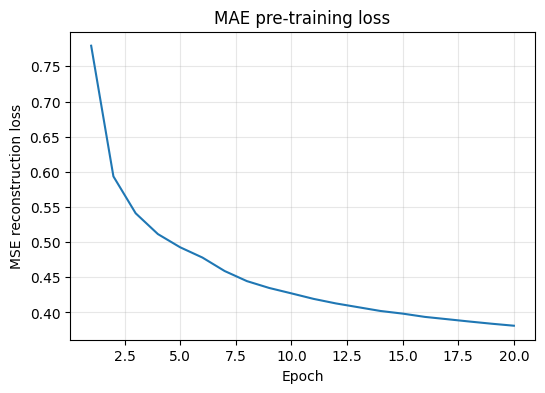

In [6]:
try:
    _ = pretrain_losses[0]
except (NameError, IndexError):
    ckpt_path = os.path.join(CKPT_DIR, 'mae_last.pt')
    assert os.path.exists(ckpt_path), "No pre-training checkpoint found — run pre-training first."
    ckpt = torch.load(ckpt_path, map_location=device)
    pretrain_losses = ckpt['losses']
    print(f"Loaded pre-training losses from checkpoint (epoch {ckpt['epoch']})")

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(pretrain_losses) + 1), pretrain_losses)
plt.xlabel('Epoch')
plt.ylabel('MSE reconstruction loss')
plt.title('MAE pre-training loss')
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\hugop\AppData\Local\Temp\ipykernel_27224\3069377402.py:20: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder     = nn.TransformerEncoder(enc_layer, num_layers=enc_num_layers)
C:\Users\hugop\AppData\Local\Temp\ipykernel_27224\3069377402.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder      = nn.TransformerEncoder(dec_layer, num_layers=dec_num_layers)


Loaded best MAE from checkpoint (epoch 20, loss 0.3811)


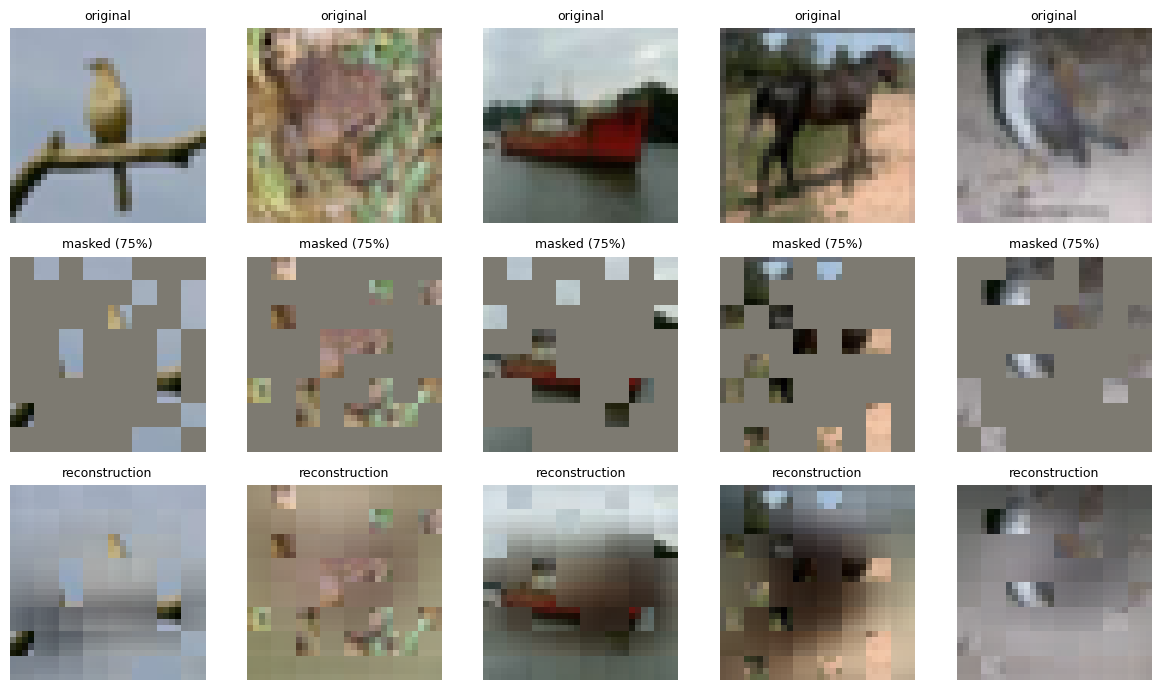

In [7]:
ckpt_path = os.path.join(CKPT_DIR, 'mae_best.pt')
assert os.path.exists(ckpt_path), "No pre-training checkpoint found — run pre-training first."
ckpt = torch.load(ckpt_path, map_location=device)

mae = MAE(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, channels=CHANNELS,
    enc_d_model=ENC_D_MODEL, enc_num_heads=ENC_NUM_HEADS,
    enc_num_layers=ENC_NUM_LAYERS, enc_d_ff=ENC_D_FF,
    dec_d_model=DEC_D_MODEL, dec_num_heads=DEC_NUM_HEADS,
    dec_num_layers=DEC_NUM_LAYERS, dec_d_ff=DEC_D_FF,
    mask_ratio=MASK_RATIO, dropout=DROPOUT,
).to(device)

mae.load_state_dict(ckpt['model'])
print(f"Loaded best MAE from checkpoint (epoch {ckpt['epoch']}, loss {ckpt['losses'][-1]:.4f})")

def unnormalize(img):
    mean = torch.tensor(MEAN).view(3, 1, 1).to(img.device)
    std  = torch.tensor(STD).view(3, 1, 1).to(img.device)
    return (img * std + mean).clamp(0, 1)

mae.eval()
indices = torch.randint(0, len(test_dataset), (5,))
fig, axes = plt.subplots(3, 5, figsize=(12, 7))

with torch.no_grad():
    for i, idx in enumerate(indices):
        img, _ = test_dataset[idx]
        img_in = img.unsqueeze(0).to(device)

        _, pred, mask = mae(img_in)

        patches      = patchify(img_in, PATCH_SIZE)
        mask_3d      = mask.unsqueeze(-1)
        masked_patch = patches * (1 - mask_3d)
        masked_img   = unpatchify(masked_patch, PATCH_SIZE, CHANNELS)

        recon_patch  = patches * (1 - mask_3d) + pred * mask_3d
        recon_img    = unpatchify(recon_patch, PATCH_SIZE, CHANNELS)

        axes[0, i].imshow(unnormalize(img).permute(1, 2, 0).cpu().numpy())
        axes[0, i].set_title('original', fontsize=9)
        axes[0, i].axis('off')

        axes[1, i].imshow(unnormalize(masked_img[0]).permute(1, 2, 0).cpu().numpy())
        axes[1, i].set_title('masked (75%)', fontsize=9)
        axes[1, i].axis('off')

        axes[2, i].imshow(unnormalize(recon_img[0]).permute(1, 2, 0).cpu().numpy())
        axes[2, i].set_title('reconstruction', fontsize=9)
        axes[2, i].axis('off')

plt.tight_layout()
plt.show()

---
# 4. Fine-tuning on CIFAR-10

In [8]:
class MAEClassifier(nn.Module):
    def __init__(self, mae, num_classes):
        super().__init__()
       
        self.patch_proj    = mae.patch_proj
        self.enc_pos_embed = mae.enc_pos_embed
        self.encoder       = mae.encoder
        self.encoder_norm  = mae.encoder_norm
        self.patch_size    = mae.patch_size

        d_model = mae.enc_pos_embed.shape[-1]
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, images):
        x = patchify(images, self.patch_size) #x(B,N,patch_dim)
        x = self.patch_proj(x) #x(B,N,enc_d_model)
        x = x + self.enc_pos_embed #x(B,N,enc_d_model)
        x = self.encoder(x) #x(B,N,enc_d_model)
        x = self.encoder_norm(x) #x(B,N,enc_d_model)
        x = x.mean(dim=1)  #(B,enc_d_model)       
        logits = self.head(x) #(B,num_classes)
        return logits

In [ ]:
FT_EPOCHS = 30
FT_LR     = 1e-3

classifier = MAEClassifier(mae, NUM_CLASSES).to(device)
optimizer  = torch.optim.AdamW(classifier.parameters(), lr=FT_LR, weight_decay=0.05)
criterion  = nn.CrossEntropyLoss()

print(f"n_params : {sum(p.numel() for p in classifier.parameters()):,}")

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total

In [ ]:
ft_train_losses, ft_test_losses = [], []
ft_train_accs,   ft_test_accs   = [], []
ft_best_acc = 0.0

for epoch in range(1, FT_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(classifier, train_loader, optimizer, criterion)
    test_loss,  test_acc  = evaluate(classifier, test_loader, criterion)

    ft_train_losses.append(train_loss)
    ft_test_losses.append(test_loss)
    ft_train_accs.append(train_acc)
    ft_test_accs.append(test_acc)

    print(f"Fine-tune epoch {epoch:2d}/{FT_EPOCHS} | "
          f"train loss {train_loss:.4f}  train acc {train_acc*100:.1f}%  | "
          f"test loss {test_loss:.4f}  test acc {test_acc*100:.1f}%")

    torch.save({
        'epoch':          epoch,
        'model':          classifier.state_dict(),
        'optimizer':      optimizer.state_dict(),
        'ft_train_losses': ft_train_losses,
        'ft_test_losses':  ft_test_losses,
        'ft_train_accs':   ft_train_accs,
        'ft_test_accs':    ft_test_accs,
    }, os.path.join(CKPT_DIR, 'classifier_last.pt'))

    if test_acc > ft_best_acc:
        ft_best_acc = test_acc
        torch.save({
            'epoch':          epoch,
            'model':          classifier.state_dict(),
            'optimizer':      optimizer.state_dict(),
            'ft_train_losses': ft_train_losses,
            'ft_test_losses':  ft_test_losses,
            'ft_train_accs':   ft_train_accs,
            'ft_test_accs':    ft_test_accs,
        }, os.path.join(CKPT_DIR, 'classifier_best.pt'))
        print(f"  → best checkpoint saved (acc {ft_best_acc*100:.1f}%)")

---
# 5. Results of the Fine-tuning

Loaded fine-tuning data from checkpoint (epoch 30)


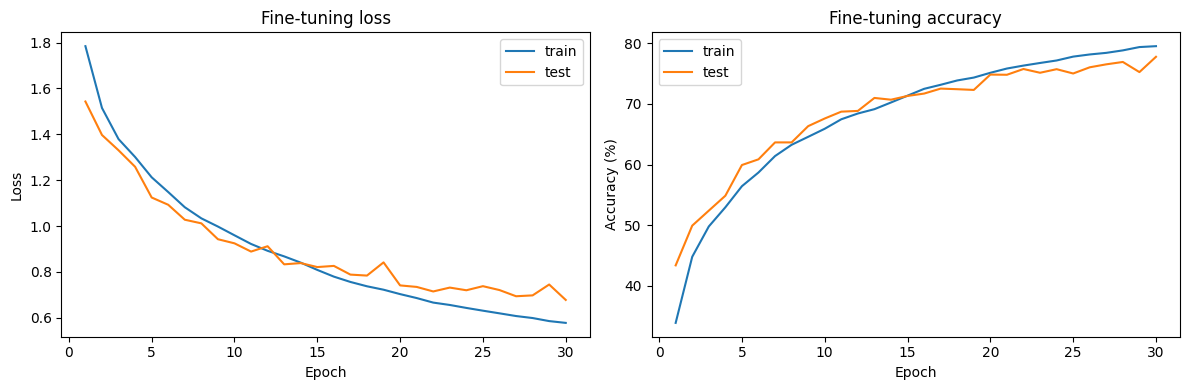

Best test accuracy : 77.8%


In [9]:
try:
    _ = ft_train_losses[0]
except (NameError, IndexError):
    ckpt_path = os.path.join(CKPT_DIR, 'classifier_last.pt')
    assert os.path.exists(ckpt_path), "No fine-tuning checkpoint found — run fine-tuning first."
    ckpt = torch.load(ckpt_path, map_location=device)
    ft_train_losses = ckpt['ft_train_losses']
    ft_test_losses  = ckpt['ft_test_losses']
    ft_train_accs   = ckpt['ft_train_accs']
    ft_test_accs    = ckpt['ft_test_accs']
    print(f"Loaded fine-tuning data from checkpoint (epoch {ckpt['epoch']})")

epochs = range(1, len(ft_train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, ft_train_losses, label='train')
ax1.plot(epochs, ft_test_losses,  label='test')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Fine-tuning loss')
ax1.legend()

ax2.plot(epochs, [a*100 for a in ft_train_accs], label='train')
ax2.plot(epochs, [a*100 for a in ft_test_accs],  label='test')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Fine-tuning accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Best test accuracy : {max(ft_test_accs)*100:.1f}%")

Loaded best classifier from checkpoint (epoch 30, acc 77.8%)


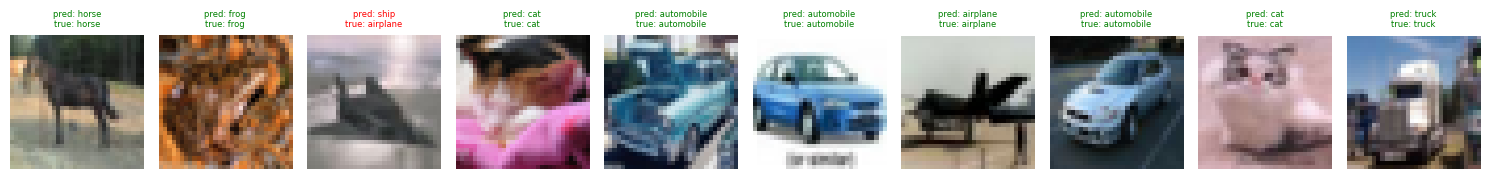

In [12]:
try:
    _ = ft_best_acc
except NameError:
    ckpt_path = os.path.join(CKPT_DIR, 'classifier_best.pt')
    assert os.path.exists(ckpt_path), "No fine-tuning checkpoint found — run fine-tuning first."
    ckpt = torch.load(ckpt_path, map_location=device)
    classifier = MAEClassifier(mae, NUM_CLASSES).to(device)
    classifier.load_state_dict(ckpt['model'])
    print(f"Loaded best classifier from checkpoint (epoch {ckpt['epoch']}, acc {max(ckpt['ft_test_accs'])*100:.1f}%)")

classifier.eval()
classes  = test_dataset.classes
indices  = torch.randint(0, len(test_dataset), (10,))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, true_label = test_dataset[idx]
    with torch.no_grad():
        logits     = classifier(img.unsqueeze(0).to(device))
        pred_label = logits.argmax(dim=1).item()

    img_display = unnormalize(img).permute(1, 2, 0).cpu().numpy()
    axes[i].imshow(img_display)
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f"pred: {classes[pred_label]}\ntrue: {classes[true_label]}",
                       fontsize=6, color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()